# Experiment: Kernel Matrix Computation (Polynomial & RBF) for Kernel PCA

## Objective
To compute the kernel (Gram) matrix using:
1) Polynomial Kernel  
2) RBF (Gaussian) Kernel  
for a given numerical dataset. This kernel matrix is required in Kernel PCA.

---

## Given Dataset (Wind dataset)
Let the dataset be:

X = {(1,2), (2,1), (3,3)}

So,
x1 = (1,2)  
x2 = (2,1)  
x3 = (3,3)

---

## Kernel Functions

### 1) Polynomial Kernel
K(xi, xj) = (xiᵀ xj + 1)²

### 2) RBF (Gaussian) Kernel
K(xi, xj) = exp( -γ ||xi - xj||² )

Where γ is a constant (choose γ = 0.1).

---

## Tasks
1. Load the dataset in Python.
2. Compute the Polynomial Kernel matrix.
3. Compute the RBF Kernel matrix.
4. Display both kernel matrices.
5. (Optional) Verify symmetry of kernel matrices.

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load dataset (Wind dataset)
X = np.array([
    [1, 2],
    [2, 1],
    [3, 3]
], dtype=float)

labels = ["x1", "x2", "x3"]

print("Dataset X:")
print(pd.DataFrame(X, index=labels, columns=["Feature1", "Feature2"]))

Dataset X:
    Feature1  Feature2
x1       1.0       2.0
x2       2.0       1.0
x3       3.0       3.0


In [3]:
# Polynomial Kernel Matrix
# K(xi, xj) = (xi^T xj + 1)^2

dot_matrix = X @ X.T                 # xi^T xj for all i,j
K_poly = (dot_matrix + 1) ** 2       # apply polynomial kernel

print("\nDot Product Matrix (X X^T):")
print(pd.DataFrame(dot_matrix, index=labels, columns=labels))

print("\nPolynomial Kernel Matrix K_poly = (X X^T + 1)^2 :")
print(pd.DataFrame(K_poly, index=labels, columns=labels))


Dot Product Matrix (X X^T):
     x1   x2    x3
x1  5.0  4.0   9.0
x2  4.0  5.0   9.0
x3  9.0  9.0  18.0

Polynomial Kernel Matrix K_poly = (X X^T + 1)^2 :
       x1     x2     x3
x1   36.0   25.0  100.0
x2   25.0   36.0  100.0
x3  100.0  100.0  361.0


In [4]:
# RBF Kernel Matrix
# K(xi, xj) = exp(-gamma * ||xi - xj||^2)
gamma = 0.1

In [5]:
# Compute squared Euclidean distance matrix
# ||xi - xj||^2 = sum((xi - xj)^2)
diff = X[:, None, :] - X[None, :, :]
dist_sq = np.sum(diff**2, axis=2)

K_rbf = np.exp(-gamma * dist_sq)

print("\nSquared Distance Matrix ||xi - xj||^2 :")
print(pd.DataFrame(dist_sq, index=labels, columns=labels))

print(f"\nRBF Kernel Matrix (gamma = {gamma}):")
print(pd.DataFrame(K_rbf, index=labels, columns=labels))


Squared Distance Matrix ||xi - xj||^2 :
     x1   x2   x3
x1  0.0  2.0  5.0
x2  2.0  0.0  5.0
x3  5.0  5.0  0.0

RBF Kernel Matrix (gamma = 0.1):
          x1        x2        x3
x1  1.000000  0.818731  0.606531
x2  0.818731  1.000000  0.606531
x3  0.606531  0.606531  1.000000


In [6]:
# Optional: Symmetry Check
print("\nSymmetry Check:")
print("K_poly symmetric?", np.allclose(K_poly, K_poly.T))
print("K_rbf symmetric?", np.allclose(K_rbf, K_rbf.T))


Symmetry Check:
K_poly symmetric? True
K_rbf symmetric? True


✅ Kernel matrix

✅ Centered kernel matrix

✅ Eigenvalues/Eigenvectors

✅ 2D Projection (Kernel PCA plot)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
X = np.array([
    [1, 2],
    [2, 1],
    [3, 3]
], dtype=float)

labels = ["x1", "x2", "x3"]

print("Dataset X:")
print(pd.DataFrame(X, index=labels, columns=["Feature1", "Feature2"]))

Dataset X:
    Feature1  Feature2
x1       1.0       2.0
x2       2.0       1.0
x3       3.0       3.0


In [9]:
# Helper: Center a kernel matrix
# Kc = K - 1K - K1 + 1K1
def center_kernel(K):
    n = K.shape[0]
    one = np.ones((n, n)) / n
    Kc = K - one @ K - K @ one + one @ K @ one
    return Kc

In [10]:
# 2) Polynomial Kernel
# K(xi, xj) = (xi^T xj + 1)^2
K_poly = (X @ X.T + 1) ** 2
K_poly_c = center_kernel(K_poly)

print("\nPolynomial Kernel Matrix (K_poly):")
print(pd.DataFrame(K_poly, index=labels, columns=labels))

print("\nCentered Polynomial Kernel Matrix (K_poly_centered):")
print(pd.DataFrame(np.round(K_poly_c, 4), index=labels, columns=labels))


Polynomial Kernel Matrix (K_poly):
       x1     x2     x3
x1   36.0   25.0  100.0
x2   25.0   36.0  100.0
x3  100.0  100.0  361.0

Centered Polynomial Kernel Matrix (K_poly_centered):
         x1       x2       x3
x1  26.7778  15.7778 -42.5556
x2  15.7778  26.7778 -42.5556
x3 -42.5556 -42.5556  85.1111


In [11]:
# 3) RBF Kernel
# K(xi, xj) = exp(-gamma * ||xi-xj||^2)
gamma = 0.1
diff = X[:, None, :] - X[None, :, :]
dist_sq = np.sum(diff**2, axis=2)

K_rbf = np.exp(-gamma * dist_sq)
K_rbf_c = center_kernel(K_rbf)

print("\nRBF Kernel Matrix (K_rbf):")
print(pd.DataFrame(np.round(K_rbf, 4), index=labels, columns=labels))

print("\nCentered RBF Kernel Matrix (K_rbf_centered):")
print(pd.DataFrame(np.round(K_rbf_c, 4), index=labels, columns=labels))


RBF Kernel Matrix (K_rbf):
        x1      x2      x3
x1  1.0000  0.8187  0.6065
x2  0.8187  1.0000  0.6065
x3  0.6065  0.6065  1.0000

Centered RBF Kernel Matrix (K_rbf_centered):
        x1      x2      x3
x1  0.1680 -0.0133 -0.1547
x2 -0.0133  0.1680 -0.1547
x3 -0.1547 -0.1547  0.3095


In [12]:
# Kernel PCA function
# Steps:
#   - Center Kernel
#   - Eigen decomposition
#   - Sort eigenvalues desc
#   - Project to top components
def kernel_pca(K_centered, n_components=2):
    eigvals, eigvecs = np.linalg.eigh(K_centered)  # for symmetric matrix

    # sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # take top components
    eigvals_top = eigvals[:n_components]
    eigvecs_top = eigvecs[:, :n_components]

    # normalize eigenvectors (standard kernel PCA step)
    eigvecs_top = eigvecs_top / np.sqrt(eigvals_top + 1e-12)

    # projection
    X_kpca = K_centered @ eigvecs_top

    return X_kpca, eigvals, eigvecs

In [13]:
# Kernel PCA using Polynomial Kernel
proj_poly, eigvals_poly, _ = kernel_pca(K_poly_c, n_components=2)

print("\nPolynomial Kernel PCA Eigenvalues:")
print(np.round(eigvals_poly, 4))

print("\nPolynomial Kernel PCA Projection (Top 2 PCs):")
print(pd.DataFrame(np.round(proj_poly, 4), index=labels, columns=["PC1", "PC2"]))


Polynomial Kernel PCA Eigenvalues:
[127.6667  11.       0.    ]

Polynomial Kernel PCA Projection (Top 2 PCs):
       PC1     PC2
x1 -4.6128 -2.3452
x2 -4.6128  2.3452
x3  9.2256  0.0000


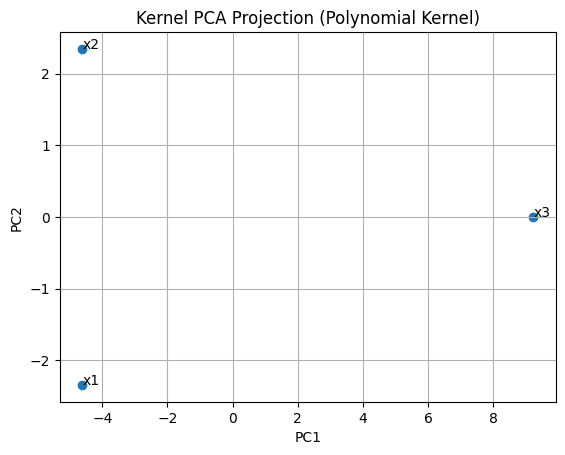

In [14]:
# Plot
plt.figure()
plt.scatter(proj_poly[:,0], proj_poly[:,1])
for i, name in enumerate(labels):
    plt.text(proj_poly[i,0], proj_poly[i,1], name)
plt.title("Kernel PCA Projection (Polynomial Kernel)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [15]:
# Kernel PCA using RBF Kernel
proj_rbf, eigvals_rbf, _ = kernel_pca(K_rbf_c, n_components=2)

print("\nRBF Kernel PCA Eigenvalues:")
print(np.round(eigvals_rbf, 4))

print("\nRBF Kernel PCA Projection (Top 2 PCs):")
print(pd.DataFrame(np.round(proj_rbf, 4), index=labels, columns=["PC1", "PC2"]))


RBF Kernel PCA Eigenvalues:
[ 0.4642  0.1813 -0.    ]

RBF Kernel PCA Projection (Top 2 PCs):
       PC1     PC2
x1 -0.2781 -0.3011
x2 -0.2781  0.3011
x3  0.5563 -0.0000


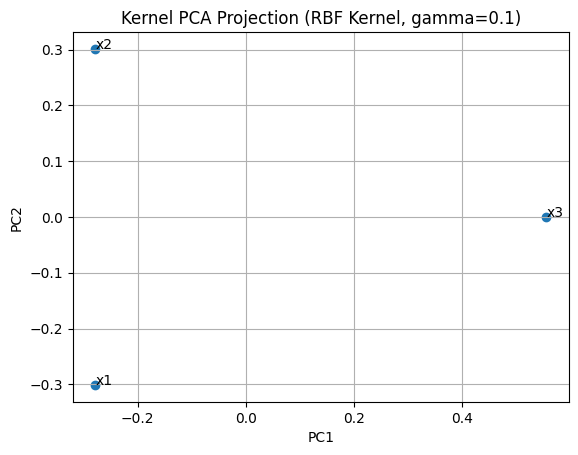

In [16]:
# Plot
plt.figure()
plt.scatter(proj_rbf[:,0], proj_rbf[:,1])
for i, name in enumerate(labels):
    plt.text(proj_rbf[i,0], proj_rbf[i,1], name)
plt.title(f"Kernel PCA Projection (RBF Kernel, gamma={gamma})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()